Importing Libraries

In [1]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error

import warnings
warnings.filterwarnings('ignore')

In [2]:
 df = pd.read_csv('D:\MLP\cardekho_imputated.csv')
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [3]:
df.shape

(15411, 14)

In [4]:
df.head(10)

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
5,5,Maruti Wagon R,Maruti,Wagon R,8,35000,Individual,Petrol,Manual,18.90,998,67.10,5,350000
6,6,Hyundai i10,Hyundai,i10,8,40000,Dealer,Petrol,Manual,20.36,1197,78.90,5,315000
7,7,Maruti Wagon R,Maruti,Wagon R,3,17512,Dealer,Petrol,Manual,20.51,998,67.04,5,410000
8,8,Hyundai Venue,Hyundai,Venue,2,20000,Individual,Petrol,Automatic,18.15,998,118.35,5,1050000
9,12,Maruti Swift,Maruti,Swift,4,28321,Dealer,Petrol,Manual,16.60,1197,85.00,5,511000


In [5]:
df.tail()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000
15410,19543,Honda City,Honda,City,2,13000,Dealer,Petrol,Automatic,18.00,1497,117.60,5,1200000


In [6]:
df.dtypes

Unnamed: 0             int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [7]:
df.isna().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [8]:
df.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [10]:
from sklearn.preprocessing import OneHotEncoder

In [11]:
encoder = OneHotEncoder(sparse_output=False)

In [12]:
df

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [13]:
df.drop(df[['Unnamed: 0','car_name']],axis=1,inplace=True)

In [14]:
df

,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [15]:
cols = ['seller_type','fuel_type','transmission_type','brand','model']

In [16]:
ds = encoder.fit_transform(df[cols])

In [17]:
Encode = pd.DataFrame(ds,columns=encoder.get_feature_names_out(cols))

In [18]:
ds = df.drop(columns=cols)

In [19]:
Data = pd.concat([ds,Encode],axis=1)
Data

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,...,model_XE,model_XF,model_XL6,model_XUV300,model_XUV500,model_Yaris,model_Z4,model_i10,model_i20,model_redi-GO
0,9,120000,19.70,796,46.30,5,120000,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5,20000,18.90,1197,82.00,5,550000,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11,60000,17.00,1197,80.00,5,215000,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,9,37000,20.92,998,67.10,5,226000,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,6,30000,22.77,1498,98.59,5,570000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,250000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
15407,2,18000,17.50,1373,91.10,7,925000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15408,6,67000,21.14,1498,103.52,5,425000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15409,5,3800000,16.00,2179,140.00,7,1225000,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [20]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Columns: 169 entries, vehicle_age to model_redi-GO
dtypes: float64(164), int64(5)
memory usage: 19.9 MB


In [21]:
Data.describe()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,...,model_XE,model_XF,model_XL6,model_XUV300,model_XUV500,model_Yaris,model_Z4,model_i10,model_i20,model_redi-GO
count,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,...,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000,15411.000000
mean,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05,0.618973,0.369801,0.011226,...,0.000260,0.003374,0.000454,0.000973,0.021413,0.001103,0.000389,0.026604,0.058789,0.000649
std,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05,0.485655,0.482766,0.105359,...,0.016109,0.057992,0.021308,0.031184,0.144762,0.033196,0.019728,0.160929,0.235237,0.025466
min,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05,1.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


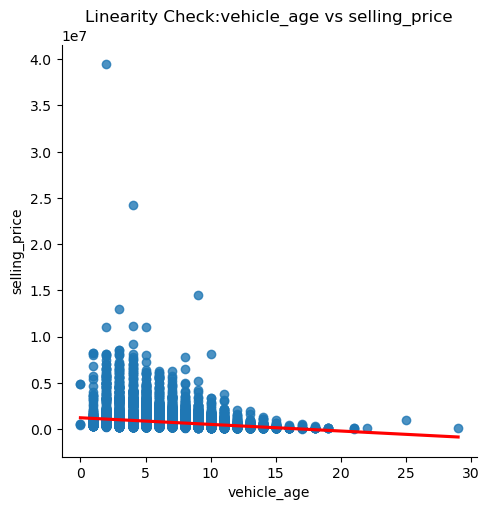

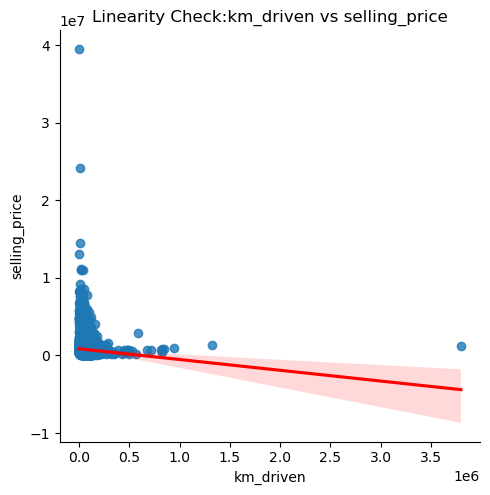

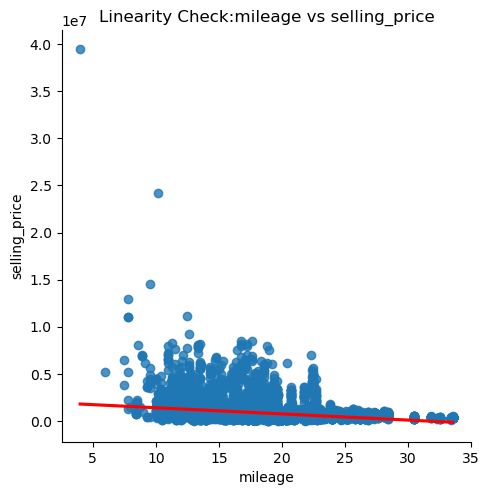

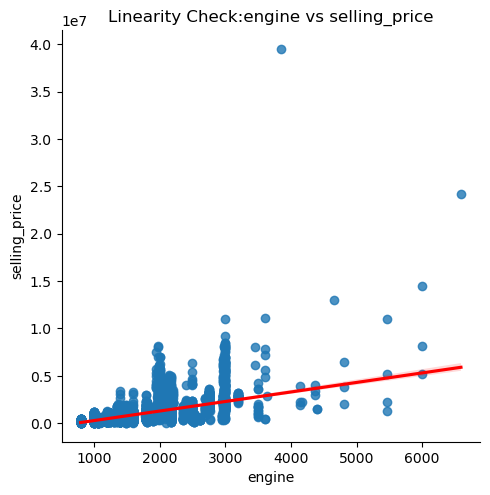

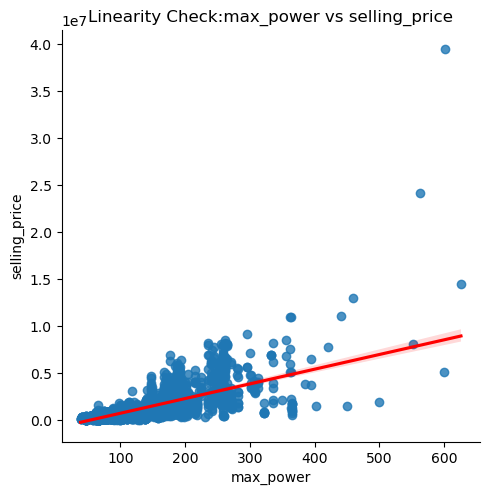

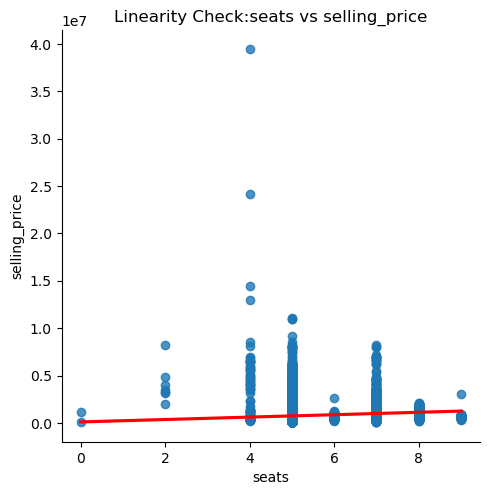

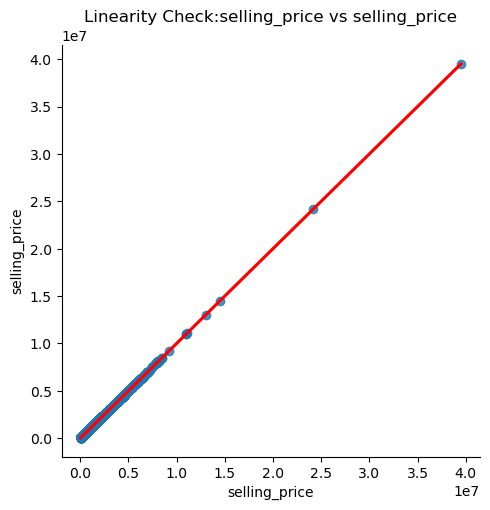

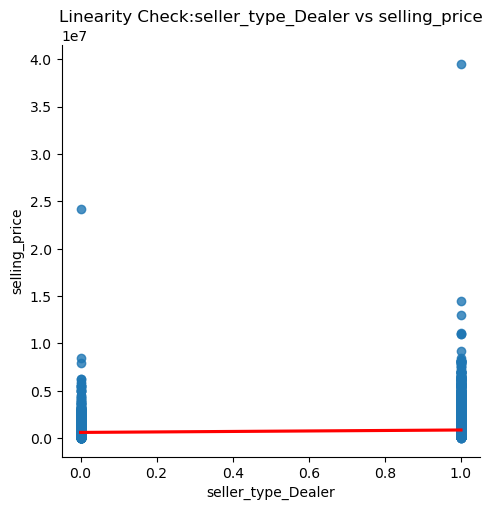

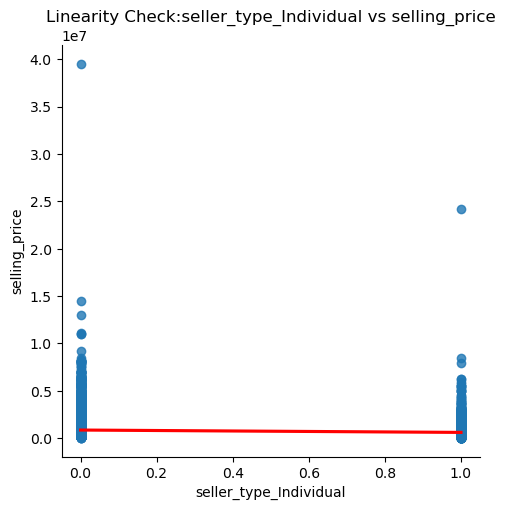

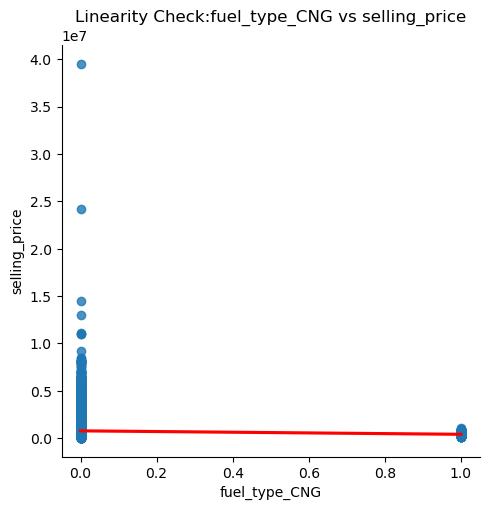

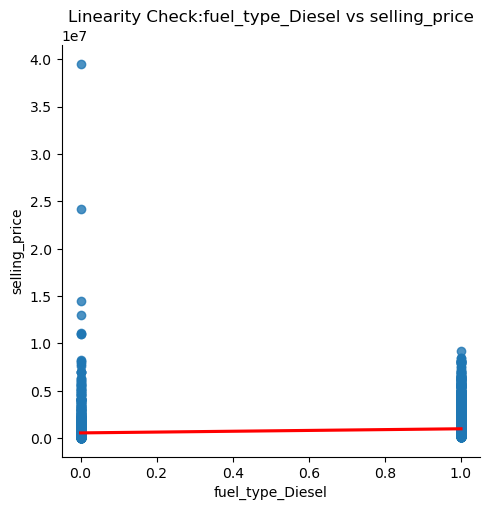

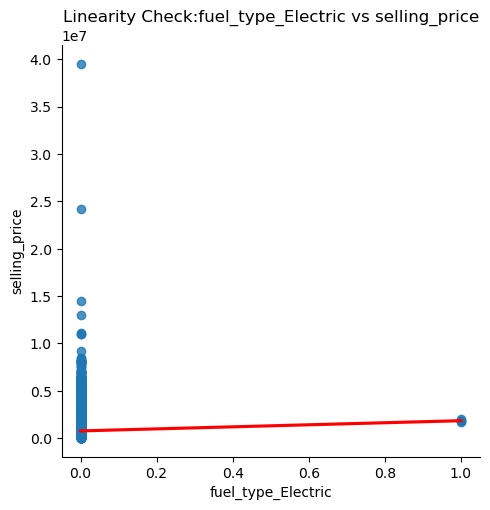

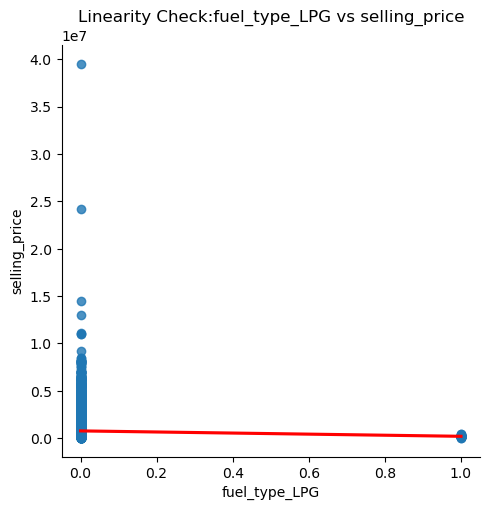

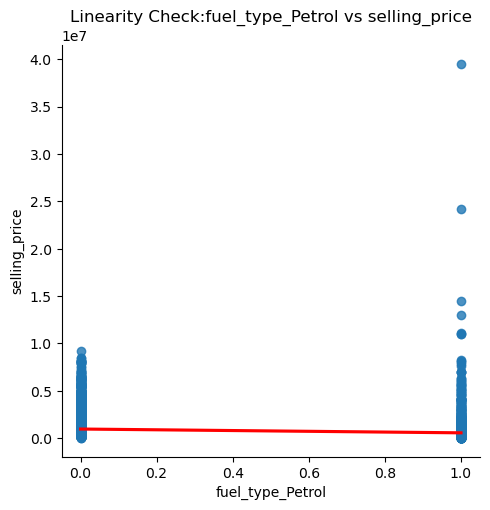

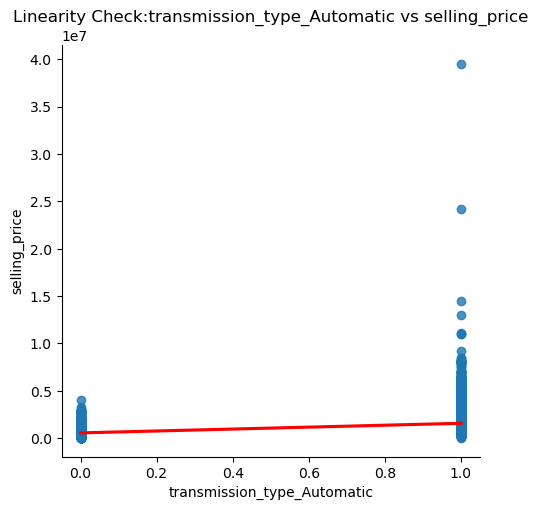

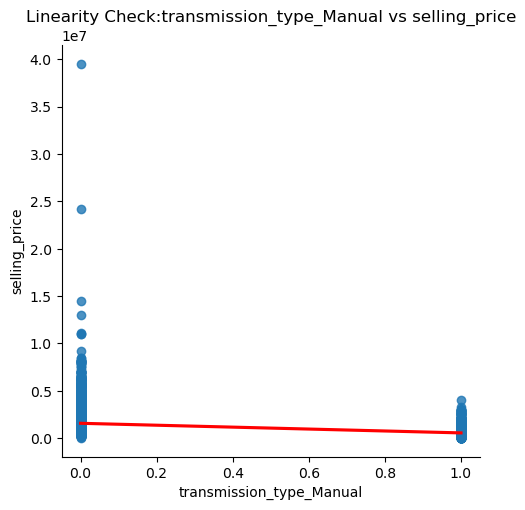

In [22]:
features = ['vehicle_age','km_driven','mileage','engine','max_power','seats','selling_price','seller_type_Dealer',	'seller_type_Individual', 	'fuel_type_CNG',	'fuel_type_Diesel',	'fuel_type_Electric',	'fuel_type_LPG',	'fuel_type_Petrol',	'transmission_type_Automatic',	'transmission_type_Manual']
target = 'selling_price'
for col in features:
    sns.lmplot(x=col, y=target, data=Data, line_kws={'color':'red'})
    plt.title(f"Linearity Check:{col} vs {target}")
    plt.show()

In [23]:
Data.corr()

,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,...,model_XE,model_XF,model_XL6,model_XUV300,model_XUV500,model_Yaris,model_Z4,model_i10,model_i20,model_redi-GO
vehicle_age,1.000000,0.333891,-0.257394,0.098965,0.005208,0.030791,-0.241851,0.045779,-0.032613,-0.061584,...,-0.016237,0.015267,-0.031588,-0.043193,-0.012495,-0.035433,0.006312,0.186559,-0.017021,-0.019758
km_driven,0.333891,1.000000,-0.105239,0.192885,0.044421,0.192830,-0.080030,-0.048814,0.060044,-0.050116,...,-0.004969,-0.010924,-0.017619,-0.024466,0.070975,-0.021911,-0.014381,0.004855,-0.024250,-0.016112
mileage,-0.257394,-0.105239,1.000000,-0.632987,-0.533128,-0.440280,-0.305549,-0.079906,0.073703,0.030610,...,-0.023665,-0.047375,-0.005766,-0.012730,-0.148184,-0.016759,-0.043424,0.006828,0.000728,0.009554
engine,0.098965,0.192885,-0.632987,1.000000,0.807368,0.551236,0.585844,0.114754,-0.103192,-0.056123,...,0.015861,0.096620,-0.000984,-0.011325,0.192326,0.000634,0.056662,-0.104505,-0.101903,-0.028707
max_power,0.005208,0.044421,-0.533128,0.807368,1.000000,0.172257,0.750236,0.185213,-0.177505,-0.040399,...,0.030539,0.145184,0.001296,0.007776,0.140484,0.003878,0.095575,-0.098505,-0.093272,-0.023864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
model_Yaris,-0.035433,-0.021911,-0.016759,0.000634,0.003878,-0.013393,0.009538,-0.002103,0.002889,-0.003541,...,-0.000535,-0.001934,-0.000708,-0.001037,-0.004916,1.000000,-0.000656,-0.005494,-0.008305,-0.000847
model_Z4,0.006312,-0.014381,-0.043424,0.056662,0.095575,-0.081265,0.081759,0.015484,-0.015118,-0.002103,...,-0.000318,-0.001148,-0.000421,-0.000616,-0.002919,-0.000656,1.000000,-0.003263,-0.004932,-0.000503
model_i10,0.186559,0.004855,0.006828,-0.104505,-0.098505,-0.066629,-0.091675,0.013468,-0.013881,0.001521,...,-0.002664,-0.009619,-0.003524,-0.005160,-0.024455,-0.005494,-0.003263,1.000000,-0.041318,-0.004213
model_i20,-0.017021,-0.024250,0.000728,-0.101903,-0.093272,-0.100724,-0.064673,-0.023738,0.018263,0.025737,...,-0.004027,-0.014542,-0.005328,-0.007801,-0.036970,-0.008305,-0.004932,-0.041318,1.000000,-0.006368


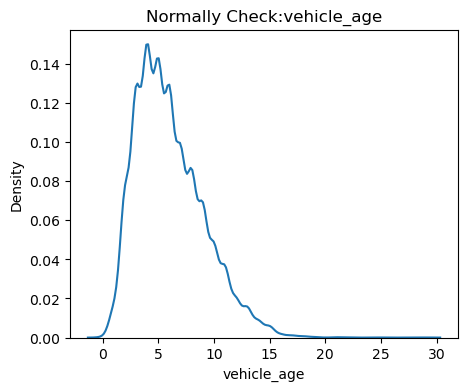

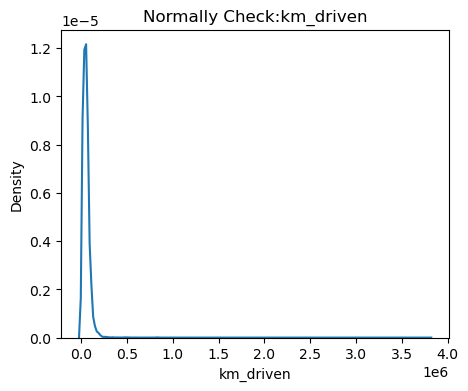

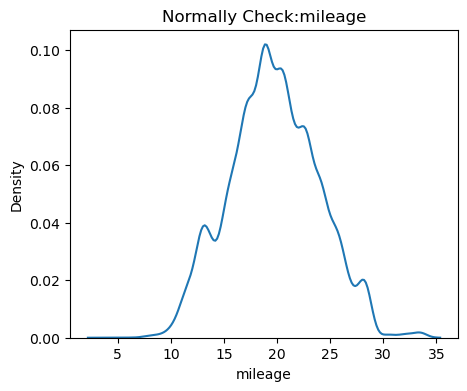

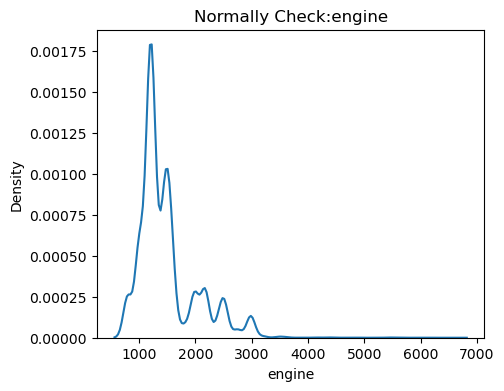

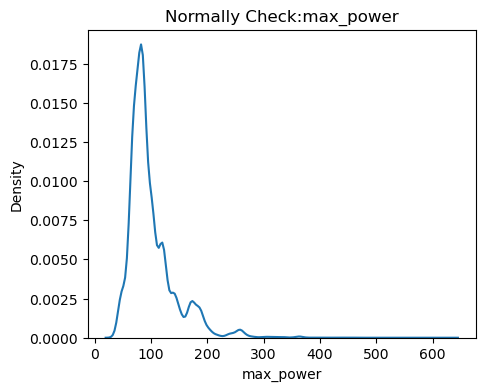

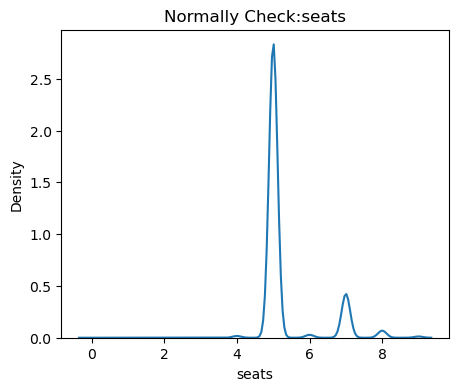

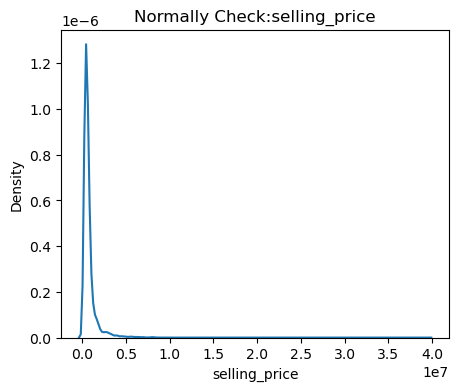

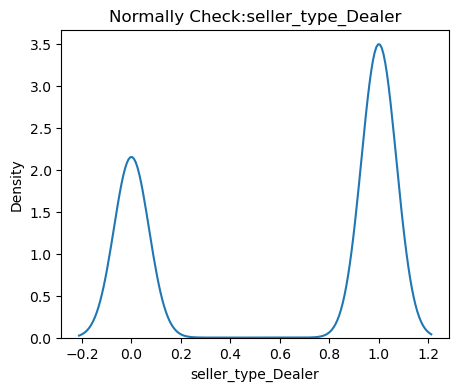

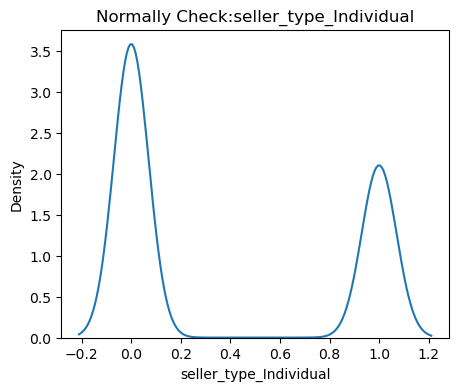

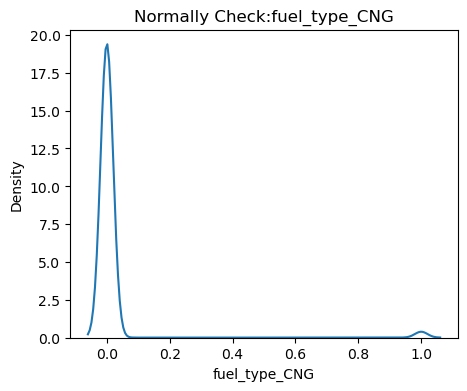

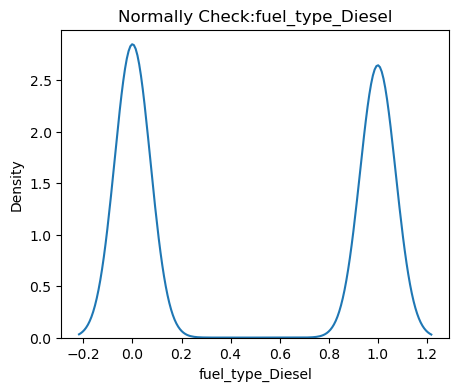

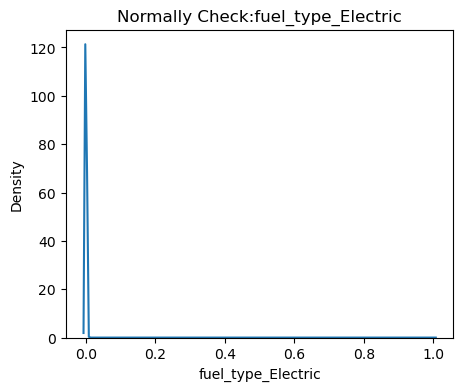

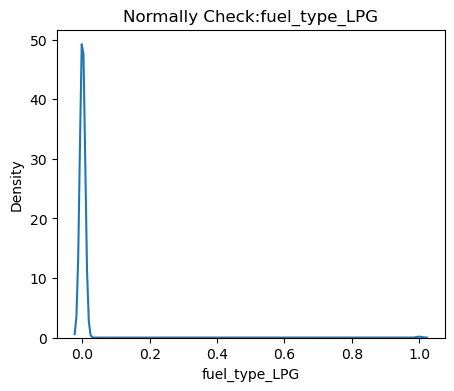

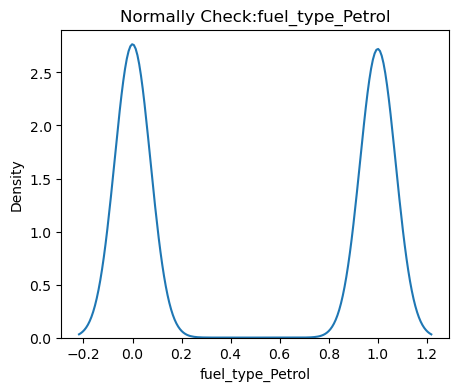

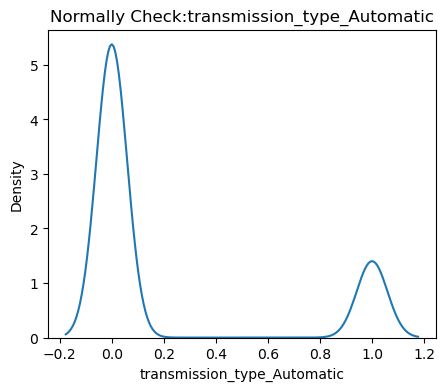

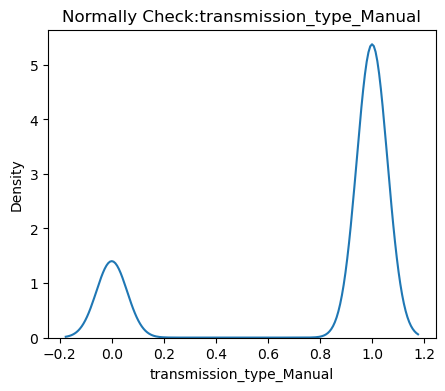

In [24]:
for col in features:
    plt.figure(figsize=(5, 4))
    sns.distplot(Data[col],hist=False)
    plt.title(f"Normally Check:{col}")
    plt.show()

In [25]:
x = Data[['vehicle_age','km_driven','mileage','engine','max_power','seats','seller_type_Dealer','seller_type_Individual', 'fuel_type_CNG','fuel_type_Diesel','fuel_type_Electric','fuel_type_LPG','fuel_type_Petrol','transmission_type_Automatic','transmission_type_Manual']]
y = Data['selling_price']

In [26]:
x

,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Dealer,seller_type_Individual,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Automatic,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,5,20000,18.90,1197,82.00,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
2,11,60000,17.00,1197,80.00,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,9,37000,20.92,998,67.10,5,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,6,30000,22.77,1498,98.59,5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15407,2,18000,17.50,1373,91.10,7,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
15408,6,67000,21.14,1498,103.52,5,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
15409,5,3800000,16.00,2179,140.00,7,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [27]:
y

0         120000
1         550000
2         215000
3         226000
4         570000
          ...   
15406     250000
15407     925000
15408     425000
15409    1225000
15410    1200000
Name: selling_price, Length: 15411, dtype: int64

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,shuffle=True,random_state=10)

In [29]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((12328, 15), (3083, 15), (12328,), (3083,))

In [30]:
mlr = LinearRegression()

In [31]:
mlr.fit(x_train,y_train)

LinearRegression()

In [32]:
y_train_pred = mlr.predict(x_train)
y_train_pred

array([ 618863.63612266,  -18949.30639607, 2104435.79903946, ...,
         78017.47447445,   46961.22449301,  592457.16154792])

In [33]:
y_test_pred = mlr.predict(x_test)
y_test_pred

array([ 812705.86629029, -138518.83429778, 1026228.79125484, ...,
       1049729.53855515, 1078938.73483148,  840264.80970408])

In [34]:
r2_score(y_test,y_test_pred)

0.5119315230700319

In [35]:
r2_score(y_train,y_train_pred)

0.6760784987852688

In [36]:
error_test = y_test - y_test_pred
error_test

5886    -178705.866290
8162     478518.834298
2250    -201228.791255
613      -58784.572937
8144    -186352.943242
             ...      
6683      11073.736802
2189     172747.410666
12299   -149729.538555
9022    -203938.734831
1094    -390264.809704
Name: selling_price, Length: 3083, dtype: float64

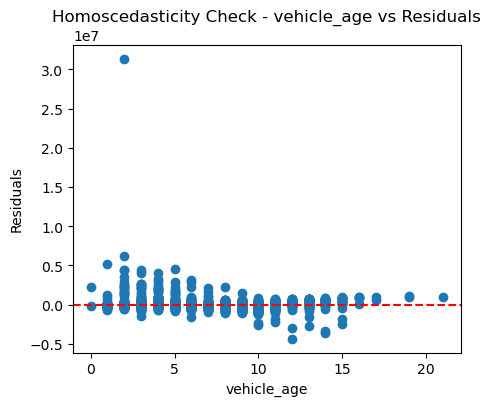

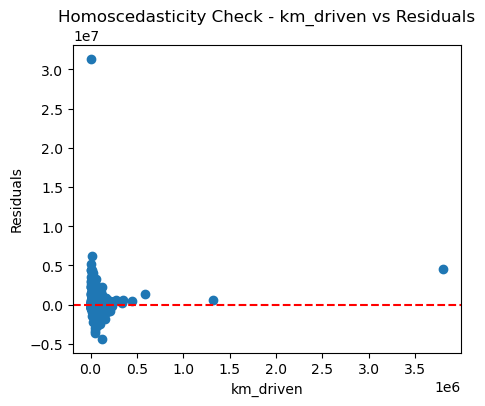

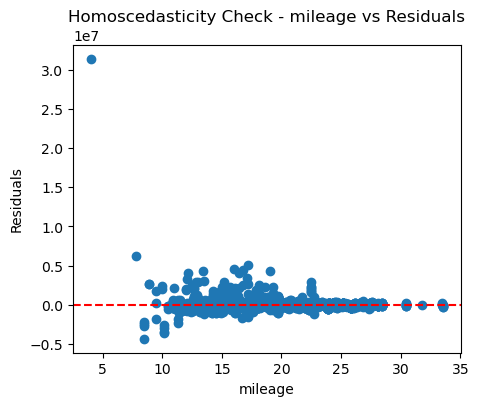

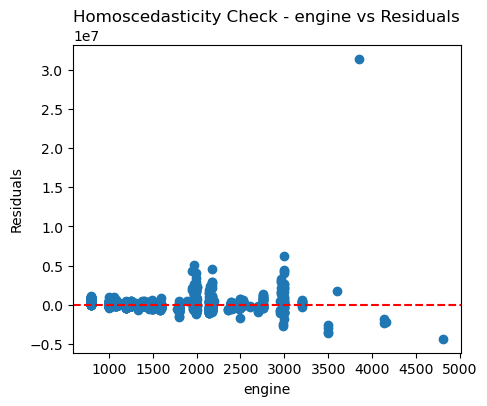

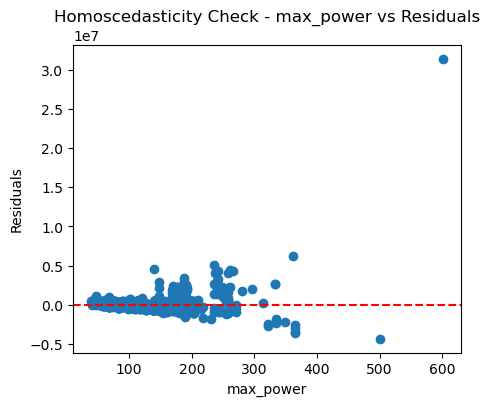

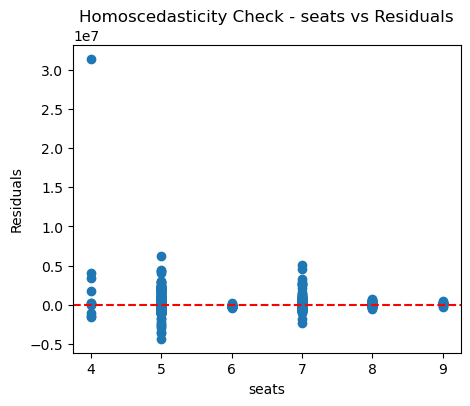

KeyError: 'selling_price'

<Figure size 500x400 with 0 Axes>

In [37]:
for col in features:
    plt.figure(figsize=(5, 4))
    plt.scatter(x=x_test[col],y=error_test)
    plt.title(f"Homoscedasticity Check - {col} vs Residuals")
    plt.xlabel(col)
    plt.ylabel('Residuals')
    plt.axhline(0, color='red', linestyle='--')
    plt.show()

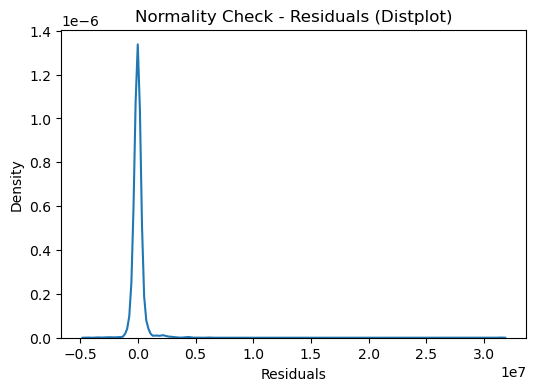

In [38]:
res = error_test.to_numpy()
res = res[np.isfinite(res)]

# Distplot for normality check 
plt.figure(figsize=(6, 4))
sns.distplot(res,hist=False)
plt.title("Normality Check - Residuals (Distplot)")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

In [ ]:
import pickle
pickel_out = open("Cars.pkl","wb")
pickle.dump(mlr, pickel_out)
pickel_out.close()

In [ ]:
!pip install streamlit

In [ ]:
!pip install --upgrade streamlit

In [ ]:
!pip install ipywidgets


In [ ]:
import ipywidgets as widgets
from IPython.display import display

display(widgets.IntSlider())
